In [ ]:
# INSIGHTS ELEITORAIS
#
# Objetivo:
# transformar os resultados das análises exploratórias e estatísticas
# em informações relevantes sobre o perfil das candidaturas.
#
# As análises deste notebook buscam identificar padrões relacionados a:
# - gênero
# - idade
# - escolaridade
# - cargo
# - cor/raça
#
# Os resultados são interpretados de forma descritiva e estatística,
# evitando inferências causais que não possam ser sustentadas pelos dados.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
import os

print("Pasta atual:")
print(os.getcwd())

print("\nArquivos e pastas:")
print(os.listdir())

Pasta atual:
C:\Users\Fernando\eleicoes-brasil-analytics\notebooks

Arquivos e pastas:
['.ipynb_checkpoints', '01_exploracao_eleicoes.ipynb', '02_exploracao_dados_tse.ipynb', '03_tratamento_candidatos.ipynb', '04_modelagem_eleicoes.ipynb', '05_analise_exploratoria_eleicoes.ipynb', '06_analise_estatistica_eleicoes.ipynb', '07_insights_eleitorais.ipynb']


In [13]:
import os

for raiz, pastas, arquivos in os.walk(".."):
    for arquivo in arquivos:
        if arquivo.endswith(".parquet"):
            print(os.path.join(raiz, arquivo))

..\data\processed\candidatos_2026.parquet
..\data\processed\dim_candidato.parquet
..\data\processed\dim_cargo.parquet
..\data\processed\dim_estado.parquet
..\data\processed\dim_partido.parquet
..\data\processed\fato_candidatura.parquet
..\venv\Lib\site-packages\pyarrow\tests\data\parquet\v0.7.1.all-named-index.parquet
..\venv\Lib\site-packages\pyarrow\tests\data\parquet\v0.7.1.column-metadata-handling.parquet
..\venv\Lib\site-packages\pyarrow\tests\data\parquet\v0.7.1.parquet
..\venv\Lib\site-packages\pyarrow\tests\data\parquet\v0.7.1.some-named-index.parquet


In [15]:
# Carregamento dos dados

arquivo = "../data/processed/candidatos_2026.parquet"

df = pd.read_parquet(arquivo)

print(f"Dimensões do dataset: {df.shape}")

Dimensões do dataset: (20721, 49)


In [16]:
df.head()

,DT_GERACAO,HH_GERACAO,ANO_ELEICAO,CD_TIPO_ELEICAO,NM_TIPO_ELEICAO,NR_TURNO,CD_ELEICAO,DS_ELEICAO,DT_ELEICAO,TP_ABRANGENCIA,...,CD_ESTADO_CIVIL,estado_civil,CD_COR_RACA,cor_raca,CD_OCUPACAO,ocupacao,CD_SIT_TOT_TURNO,situacao_final,idade,tipo_cargo
0,24/08/2026,16:31:10,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,04/10/2026,ESTADUAL,...,3,CASADO(A),3,PARDA,999,OUTROS,-1,Não informado,65,Legislativo
1,24/08/2026,16:31:10,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,04/10/2026,ESTADUAL,...,3,CASADO(A),1,BRANCA,602,PECUARISTA,-1,Não informado,61,Legislativo
2,24/08/2026,16:31:10,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,04/10/2026,ESTADUAL,...,1,SOLTEIRO(A),1,BRANCA,142,PROFESSOR DE ENSINO SUPERIOR,-1,Não informado,72,Legislativo
3,24/08/2026,16:31:10,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,04/10/2026,ESTADUAL,...,1,SOLTEIRO(A),3,PARDA,931,"ESTUDANTE, BOLSISTA, ESTAGIÁRIO E ASSEMELHADOS",-1,Não informado,31,Executivo
4,24/08/2026,16:31:10,2026,2,ELEIÇÃO ORDINÁRIA,1,6259,Eleições Gerais Estaduais 2026,04/10/2026,ESTADUAL,...,3,CASADO(A),5,INDÍGENA,999,OUTROS,-1,Não informado,44,Legislativo


In [17]:
df.columns.tolist()

['DT_GERACAO',
 'HH_GERACAO',
 'ANO_ELEICAO',
 'CD_TIPO_ELEICAO',
 'NM_TIPO_ELEICAO',
 'NR_TURNO',
 'CD_ELEICAO',
 'DS_ELEICAO',
 'DT_ELEICAO',
 'TP_ABRANGENCIA',
 'estado',
 'SG_UE',
 'estado_nome',
 'CD_CARGO',
 'cargo',
 'SQ_CANDIDATO',
 'NR_CANDIDATO',
 'nome_candidato',
 'nome_urna',
 'NM_SOCIAL_CANDIDATO',
 'CD_SITUACAO_CANDIDATURA',
 'DS_SITUACAO_CANDIDATURA',
 'TP_AGREMIACAO',
 'NR_PARTIDO',
 'partido',
 'nome_partido',
 'NR_FEDERACAO',
 'NM_FEDERACAO',
 'SG_FEDERACAO',
 'DS_COMPOSICAO_FEDERACAO',
 'SQ_COLIGACAO',
 'NM_COLIGACAO',
 'DS_COMPOSICAO_COLIGACAO',
 'SG_UF_NASCIMENTO',
 'DT_NASCIMENTO',
 'CD_GENERO',
 'genero',
 'CD_GRAU_INSTRUCAO',
 'escolaridade',
 'CD_ESTADO_CIVIL',
 'estado_civil',
 'CD_COR_RACA',
 'cor_raca',
 'CD_OCUPACAO',
 'ocupacao',
 'CD_SIT_TOT_TURNO',
 'situacao_final',
 'idade',
 'tipo_cargo']

In [18]:
# Perfil geral das candidaturas

total_candidaturas = len(df)

print(f"Total de candidaturas: {total_candidaturas:,}")
print()

print("Distribuição por gênero:")
print(df["genero"].value_counts())
print()

print("Distribuição por cargo:")
print(df["cargo"].value_counts())

Total de candidaturas: 20,721

Distribuição por gênero:
genero
MASCULINO    13492
FEMININO      7229
Name: count, dtype: int64

Distribuição por cargo:
cargo
DEPUTADO ESTADUAL     11191
DEPUTADO FEDERAL       7707
DEPUTADO DISTRITAL      429
2º SUPLENTE             328
1º SUPLENTE             325
SENADOR                 316
VICE-GOVERNADOR         201
GOVERNADOR              198
PRESIDENTE               13
VICE-PRESIDENTE          13
Name: count, dtype: int64


In [19]:
# Participação percentual por gênero

genero_percentual = (
    df["genero"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

genero_percentual

genero
MASCULINO    65.11
FEMININO     34.89
Name: proportion, dtype: float64

In [20]:
# Participação percentual por cargo

cargo_percentual = (
    df["cargo"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

cargo_percentual

cargo
DEPUTADO ESTADUAL     54.01
DEPUTADO FEDERAL      37.19
DEPUTADO DISTRITAL     2.07
2º SUPLENTE            1.58
1º SUPLENTE            1.57
SENADOR                1.53
VICE-GOVERNADOR        0.97
GOVERNADOR             0.96
PRESIDENTE             0.06
VICE-PRESIDENTE        0.06
Name: proportion, dtype: float64

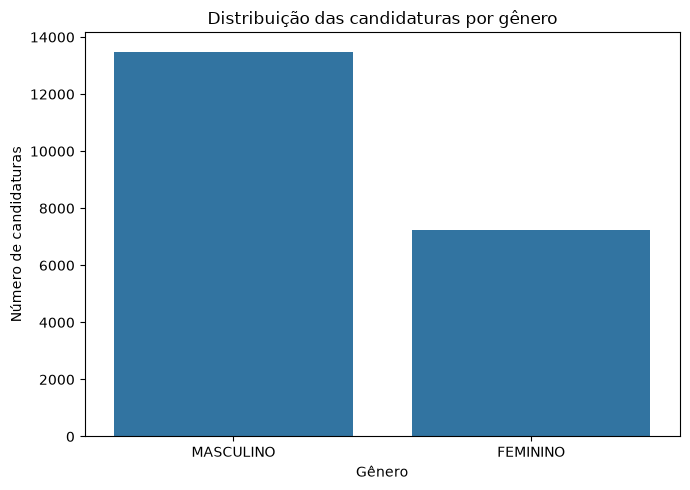

In [21]:
# Distribuição das candidaturas por gênero

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="genero"
)

plt.title("Distribuição das candidaturas por gênero")
plt.xlabel("Gênero")
plt.ylabel("Número de candidaturas")

plt.tight_layout()
plt.show()

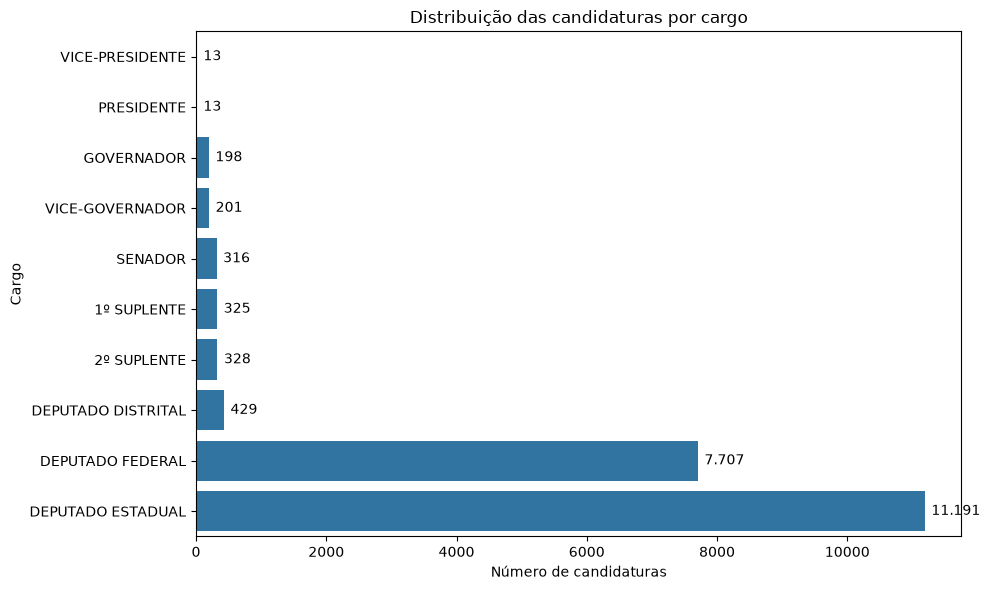

In [22]:
# Distribuição das candidaturas por cargo

cargo_contagem = df["cargo"].value_counts().sort_values(ascending=True)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    x=cargo_contagem.values,
    y=cargo_contagem.index
)

plt.title("Distribuição das candidaturas por cargo")
plt.xlabel("Número de candidaturas")
plt.ylabel("Cargo")

for i, valor in enumerate(cargo_contagem.values):
    ax.text(
        valor + 100,
        i,
        f"{valor:,}".replace(",", "."),
        va="center"
    )

plt.tight_layout()
plt.show()

In [23]:
# Composição de gênero por cargo

genero_cargo_pct = pd.crosstab(
    df["cargo"],
    df["genero"],
    normalize="index"
).mul(100).round(2)

genero_cargo_pct

genero,FEMININO,MASCULINO
cargo,,
1º SUPLENTE,30.15,69.85
2º SUPLENTE,31.10,68.90
DEPUTADO DISTRITAL,35.20,64.80
DEPUTADO ESTADUAL,34.50,65.50
DEPUTADO FEDERAL,36.60,63.40
GOVERNADOR,17.17,82.83
PRESIDENTE,15.38,84.62
SENADOR,22.15,77.85
VICE-GOVERNADOR,42.29,57.71


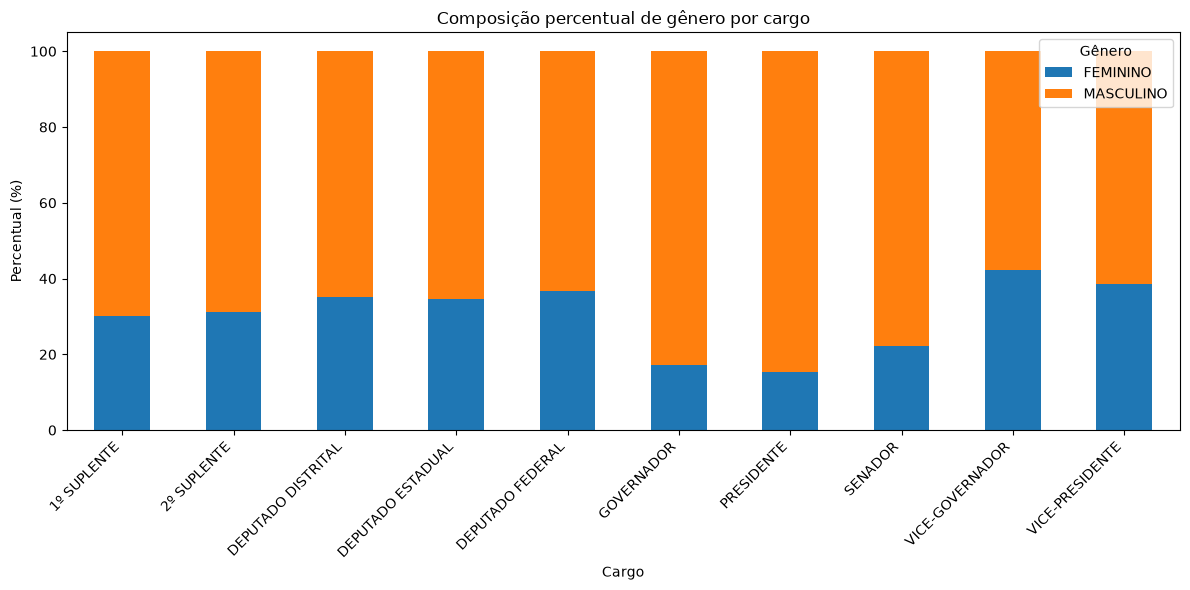

In [24]:
# Composição percentual de gênero por cargo

ax = genero_cargo_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 6)
)

plt.title("Composição percentual de gênero por cargo")
plt.xlabel("Cargo")
plt.ylabel("Percentual (%)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Gênero")

plt.tight_layout()
plt.show()

In [25]:
# Cargos com maior e menor participação feminina

maior_participacao_feminina = genero_cargo_pct["FEMININO"].sort_values(ascending=False)

print("Participação feminina por cargo:")
print(maior_participacao_feminina)

Participação feminina por cargo:
cargo
VICE-GOVERNADOR       42.29
VICE-PRESIDENTE       38.46
DEPUTADO FEDERAL      36.60
DEPUTADO DISTRITAL    35.20
DEPUTADO ESTADUAL     34.50
2º SUPLENTE           31.10
1º SUPLENTE           30.15
SENADOR               22.15
GOVERNADOR            17.17
PRESIDENTE            15.38
Name: FEMININO, dtype: float64


In [ ]:
## Insight 1: participação feminina varia conforme o cargo

A distribuição das candidaturas apresenta predominância masculina em todos os cargos analisados. Entretanto, a participação feminina varia entre as diferentes posições eleitorais.

A maior proporção de candidaturas femininas ocorre para o cargo de vice-governador, com 42,29%, seguida por vice-presidente, com 38,46%. Entre os cargos legislativos, a maior participação feminina é observada entre candidatos a deputado federal, com 36,60%.

Por outro lado, os menores percentuais de participação feminina aparecem nas candidaturas à Presidência (15,38%), ao Governo estadual (17,17%) e ao Senado (22,15%).

Essa diferença é consistente com o teste do qui-quadrado realizado na análise estatística, que indicou associação estatisticamente significativa entre gênero e cargo (χ² = 73,0353; p < 0,001). Entretanto, o V de Cramér (V = 0,0594) indica que a magnitude dessa associação é pequena.

Assim, os resultados indicam que a composição de gênero não é uniforme entre os cargos, embora a associação observada apresente baixa magnitude.

In [26]:
# Idade média das candidaturas por gênero

idade_genero = (
    df.groupby("genero")["idade"]
    .agg(["mean", "median"])
    .round(2)
)

idade_genero.columns = ["Média", "Mediana"]

idade_genero

,Média,Mediana
genero,,
FEMININO,47.75,47.0
MASCULINO,50.02,49.0


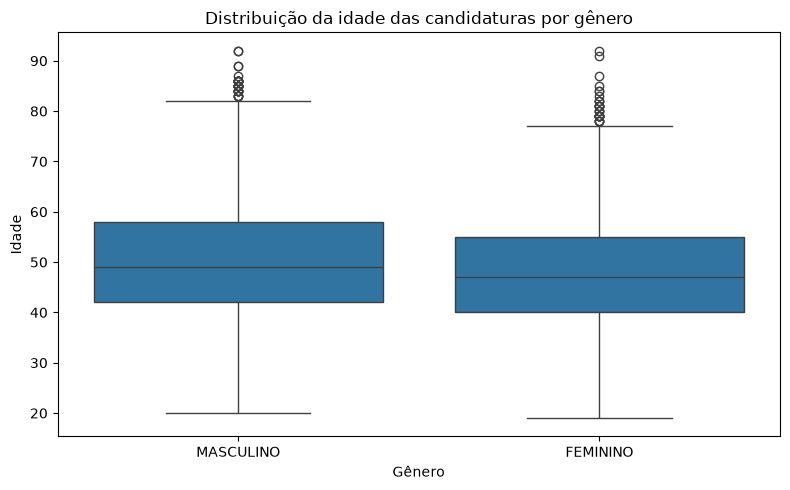

In [27]:
# Distribuição da idade média por gênero

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="genero",
    y="idade"
)

plt.title("Distribuição da idade das candidaturas por gênero")
plt.xlabel("Gênero")
plt.ylabel("Idade")

plt.tight_layout()
plt.show()

In [ ]:
## Insight 2: candidaturas femininas apresentam menor idade média

As candidaturas femininas apresentam idade média de 47,75 anos, enquanto as candidaturas masculinas apresentam média de 50,02 anos. A diferença entre as médias é de aproximadamente 2,27 anos.

O teste de Welch indicou que essa diferença é estatisticamente significativa (p < 0,001), com intervalo de confiança de 95% entre -2,60 e -1,94 anos.

Apesar da significância estatística, o tamanho do efeito é pequeno (Cohen's d = -0,1946), indicando que a diferença entre os grupos possui baixa magnitude prática.

Assim, os dados indicam que as candidaturas femininas apresentam, em média, idade inferior às candidaturas masculinas, embora a diferença observada seja relativamente pequena.

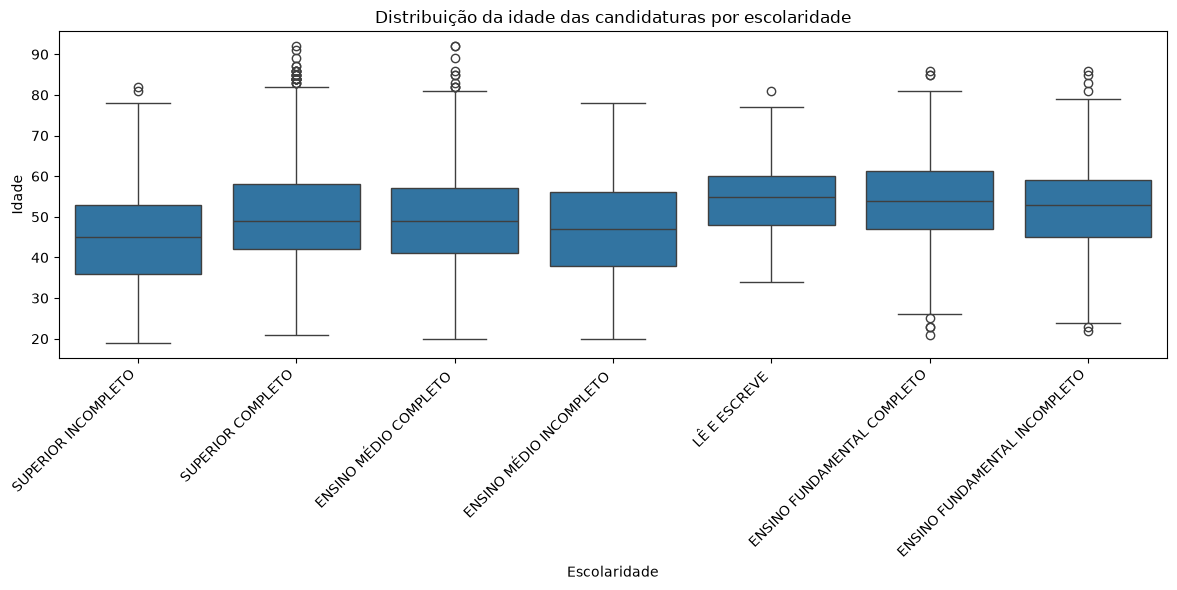

In [28]:
# Distribuição da idade por escolaridade

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="escolaridade",
    y="idade"
)

plt.title("Distribuição da idade das candidaturas por escolaridade")
plt.xlabel("Escolaridade")
plt.ylabel("Idade")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

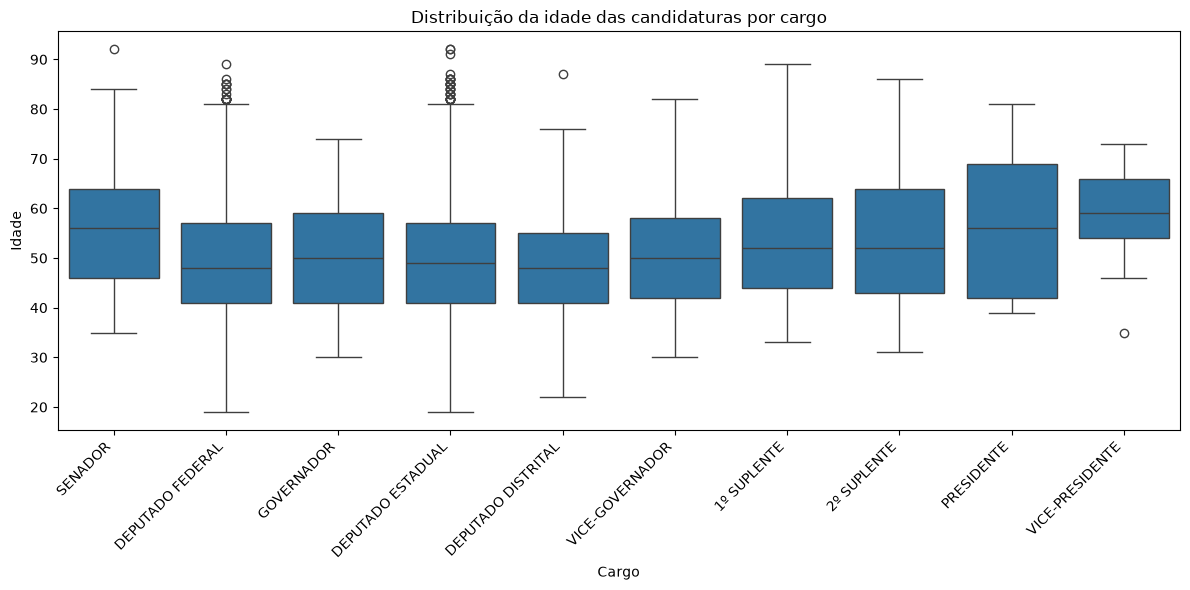

In [29]:
# Distribuição da idade das candidaturas por cargo

plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="cargo",
    y="idade"
)

plt.title("Distribuição da idade das candidaturas por cargo")
plt.xlabel("Cargo")
plt.ylabel("Idade")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [ ]:
## Insight 4: idade das candidaturas varia conforme o cargo

A idade das candidaturas apresenta diferenças entre os cargos disputados. As menores idades médias foram observadas entre candidatos a deputado distrital (47,99 anos), deputado federal (48,76 anos) e deputado estadual (49,10 anos). Em contraste, as maiores médias foram registradas entre candidatos a vice-presidente (58,08 anos), presidente (57,46 anos) e senador (55,39 anos).

A análise de variância indicou diferença estatisticamente significativa entre as idades médias dos cargos (F = 24,0180; p < 0,001). Entretanto, o tamanho do efeito foi pequeno (η² = 0,0103), indicando que o cargo explica apenas uma pequena parcela da variabilidade observada na idade das candidaturas.

As comparações realizadas pelo teste de Tukey mostraram que as diferenças não ocorrem entre todos os cargos. Por exemplo, não foram observadas diferenças estatisticamente significativas entre presidente e senador, enquanto diferenças significativas foram identificadas entre alguns cargos legislativos e cargos de maior idade média.

Assim, os resultados indicam que existe uma associação entre o cargo disputado e a idade das candidaturas, com tendência de candidaturas mais velhas em determinados cargos, mas a magnitude dessa diferença é relativamente pequena.

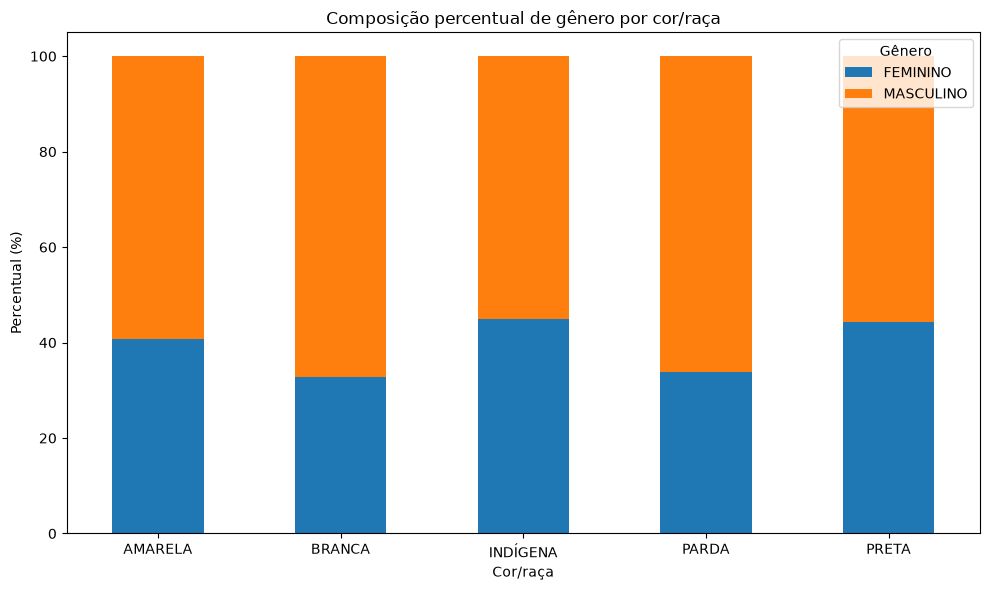

In [30]:
# Composição percentual de gênero por cor/raça

genero_raca_pct = pd.crosstab(
    df["cor_raca"],
    df["genero"],
    normalize="index"
) * 100

genero_raca_pct = genero_raca_pct.round(2)

ax = genero_raca_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Composição percentual de gênero por cor/raça")
plt.xlabel("Cor/raça")
plt.ylabel("Percentual (%)")
plt.xticks(rotation=0)
plt.legend(title="Gênero")

plt.tight_layout()
plt.show()

In [ ]:
## Insight 5: composição de gênero apresenta diferenças conforme cor/raça

A composição de gênero das candidaturas varia entre os diferentes grupos de cor/raça. A maior participação feminina foi observada entre candidatos indígenas (44,84%) e pretos (44,39%), enquanto os menores percentuais ocorreram entre candidatos brancos (32,80%) e pardos (33,81%).

O teste do qui-quadrado indicou associação estatisticamente significativa entre cor/raça e gênero (χ² = 145,6734; p < 0,001). Entretanto, o V de Cramér foi de 0,0838, indicando que a magnitude dessa associação é baixa.

A análise dos resíduos padronizados permite identificar onde estão concentradas as principais diferenças em relação às frequências esperadas. O grupo de candidaturas pretas apresentou um excesso expressivo de mulheres (resíduo padronizado = 8,54) e uma quantidade inferior à esperada de homens (−6,25). Entre candidaturas brancas, ocorreu o padrão inverso, com menos mulheres do que o esperado (−3,59) e mais homens (2,62).

Assim, os resultados indicam que a composição de gênero não é uniforme entre os grupos de cor/raça, com destaque para a maior participação feminina entre candidaturas pretas e indígenas. Apesar da significância estatística, a baixa magnitude do V de Cramér indica que essa associação deve ser interpretada como uma diferença de composição, e não como uma relação de grande intensidade.

In [31]:
# Verificação da situação final da candidatura

print("Valores da situação final:")
print(df["situacao_final"].value_counts(dropna=False))

print("\nValores únicos:")
print(df["situacao_final"].unique())

Valores da situação final:
situacao_final
Não informado    20721
Name: count, dtype: int64

Valores únicos:
<ArrowStringArray>
['Não informado']
Length: 1, dtype: str


In [ ]:
## Observação: situação final da candidatura

A variável `situacao_final` não apresenta variabilidade na base analisada. Todas as 20.721 candidaturas possuem o valor "Não informado". Dessa forma, a variável não permite realizar análises comparativas ou inferenciais sobre a situação final das candidaturas neste conjunto de dados.

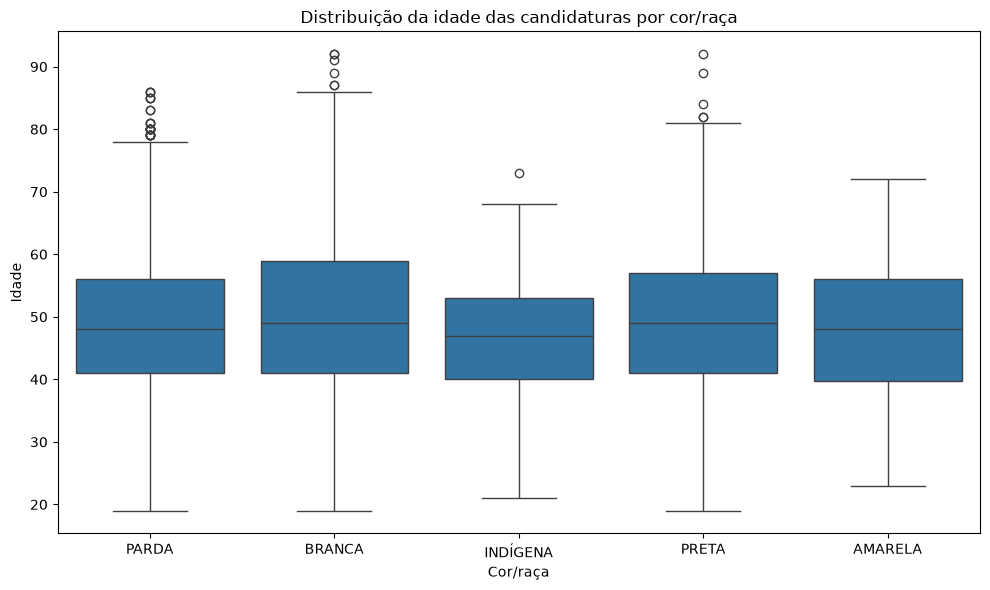

In [32]:
# Distribuição da idade das candidaturas por cor/raça

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="cor_raca",
    y="idade"
)

plt.title("Distribuição da idade das candidaturas por cor/raça")
plt.xlabel("Cor/raça")
plt.ylabel("Idade")

plt.tight_layout()
plt.show()

In [33]:
# Estatísticas de idade por cor/raça

idade_raca = (
    df.groupby("cor_raca")["idade"]
    .agg(
        Media="mean",
        Mediana="median",
        Minima="min",
        Maxima="max",
        Desvio_Padrao="std",
        Quantidade="count"
    )
    .reset_index()
)

idade_raca

,cor_raca,Media,Mediana,Minima,Maxima,Desvio_Padrao,Quantidade
0,AMARELA,47.666667,48.0,23,72,11.365631,108
1,BRANCA,50.014201,49.0,19,92,12.210197,10281
2,INDÍGENA,46.680412,47.0,21,73,9.719428,194
3,PARDA,48.453689,48.0,19,86,11.029394,7320
4,PRETA,48.637686,49.0,19,92,11.599810,2818


In [35]:
from scipy import stats

In [36]:
# ANOVA: idade por cor/raça

grupos_raca = [
    grupo["idade"].values
    for _, grupo in df.groupby("cor_raca")
]

estatistica_f_raca, p_valor_raca = stats.f_oneway(*grupos_raca)

print(f"Estatística F: {estatistica_f_raca:.4f}")
print(f"p-valor: {p_valor_raca:.6f}")

Estatística F: 24.2087
p-valor: 0.000000


In [37]:
# Tamanho do efeito da ANOVA: Eta quadrado

ss_entre_raca = sum(
    len(grupo) * (grupo["idade"].mean() - df["idade"].mean()) ** 2
    for _, grupo in df.groupby("cor_raca")
)

ss_total = sum(
    (df["idade"] - df["idade"].mean()) ** 2
)

eta_quadrado_raca = ss_entre_raca / ss_total

print(f"Eta quadrado (η²): {eta_quadrado_raca:.4f}")

Eta quadrado (η²): 0.0047


In [38]:
# Teste de Tukey: comparação entre os níveis de cor/raça

from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey_raca = pairwise_tukeyhsd(
    endog=df["idade"],
    groups=df["cor_raca"],
    alpha=0.05
)

print(tukey_raca)

  Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1   group2  meandiff p-adj   lower   upper  reject
--------------------------------------------------------
 AMARELA   BRANCA   2.3475  0.231 -0.7389   5.434  False
 AMARELA INDÍGENA  -0.9863  0.956 -4.8171  2.8445  False
 AMARELA    PARDA    0.787 0.9578 -2.3059  3.8799  False
 AMARELA    PRETA    0.971 0.9159 -2.1576  4.0996  False
  BRANCA INDÍGENA  -3.3338 0.0008 -5.6462 -1.0214   True
  BRANCA    PARDA  -1.5605    0.0 -2.0485 -1.0725   True
  BRANCA    PRETA  -1.3765    0.0  -2.055  -0.698   True
INDÍGENA    PARDA   1.7733 0.2269 -0.5477  4.0943  False
INDÍGENA    PRETA   1.9573   0.16 -0.4111  4.3257  False
   PARDA    PRETA    0.184 0.9544 -0.5234  0.8914  False
--------------------------------------------------------


In [ ]:
## Insight 3: idade das candidaturas varia segundo cor/raça

A idade das candidaturas apresenta diferenças entre os grupos de cor/raça. A maior idade média foi observada entre candidatos autodeclarados brancos, com 50,01 anos, enquanto a menor média foi registrada entre candidatos indígenas, com 46,68 anos.

A análise de variância indicou diferença estatisticamente significativa entre as idades médias dos grupos (F = 24,2087; p < 0,001). Entretanto, o tamanho do efeito foi muito pequeno (η² = 0,0047), indicando que a cor/raça explica aproximadamente 0,47% da variabilidade observada na idade das candidaturas.

As comparações realizadas pelo teste de Tukey mostraram diferenças estatisticamente significativas entre candidaturas brancas e indígenas, brancas e pardas e brancas e pretas (p < 0,001). Nas demais comparações, não foram observadas diferenças estatisticamente significativas.

Assim, os resultados indicam que existem diferenças estatisticamente significativas na idade das candidaturas segundo a cor/raça, principalmente entre candidatos brancos e os grupos indígena, pardo e preto. Contudo, a baixa magnitude do efeito indica que essas diferenças possuem pouca relevância prática para explicar a variação da idade das candidaturas.

In [ ]:
## Insight 4: composição de gênero varia conforme cor/raça

A composição de gênero das candidaturas apresenta diferenças entre os grupos de cor/raça. Embora as candidaturas masculinas sejam predominantes em todas as categorias, a participação feminina varia entre os diferentes grupos.

A maior proporção de candidaturas femininas foi observada entre candidatos indígenas, com 44,84%, seguida pelos candidatos pretos, com 44,39%, e amarelos, com 40,74%. Entre os candidatos brancos, a participação feminina foi de 32,80%, enquanto entre os candidatos pardos foi de 33,81%.

O teste do qui-quadrado indicou associação estatisticamente significativa entre gênero e cor/raça (χ² = 145,6734; p < 0,001). Entretanto, o V de Cramér foi de 0,0838, indicando uma associação de baixa magnitude.

A análise dos resíduos padronizados mostrou que as principais diferenças estão concentradas nas categorias branca e preta. Entre as candidaturas brancas, houve menos mulheres e mais homens do que o esperado pelo modelo de independência. Entre as candidaturas pretas, ocorreu o padrão inverso, com maior presença feminina e menor presença masculina do que o esperado. Também foi observada uma presença feminina acima do esperado entre as candidaturas indígenas.

Assim, os resultados indicam que a composição de gênero não é uniforme entre os grupos de cor/raça, especialmente entre candidaturas pretas e brancas. Apesar da significância estatística, a baixa magnitude do V de Cramér indica que a associação observada possui efeito relativamente pequeno.

In [39]:
# Gênero × escolaridade

tabela_genero_escolaridade = pd.crosstab(
    df["escolaridade"],
    df["genero"]
)

tabela_genero_escolaridade

genero,FEMININO,MASCULINO
escolaridade,,
ENSINO FUNDAMENTAL COMPLETO,151,385
ENSINO FUNDAMENTAL INCOMPLETO,182,433
ENSINO MÉDIO COMPLETO,1526,2921
ENSINO MÉDIO INCOMPLETO,231,491
LÊ E ESCREVE,24,51
SUPERIOR COMPLETO,4343,7793
SUPERIOR INCOMPLETO,772,1418


In [40]:
# Composição percentual de gênero por escolaridade

tabela_genero_escolaridade_pct = (
    tabela_genero_escolaridade
    .div(tabela_genero_escolaridade.sum(axis=1), axis=0)
    .mul(100)
    .round(2)
)

tabela_genero_escolaridade_pct

genero,FEMININO,MASCULINO
escolaridade,,
ENSINO FUNDAMENTAL COMPLETO,28.17,71.83
ENSINO FUNDAMENTAL INCOMPLETO,29.59,70.41
ENSINO MÉDIO COMPLETO,34.32,65.68
ENSINO MÉDIO INCOMPLETO,31.99,68.01
LÊ E ESCREVE,32.00,68.00
SUPERIOR COMPLETO,35.79,64.21
SUPERIOR INCOMPLETO,35.25,64.75


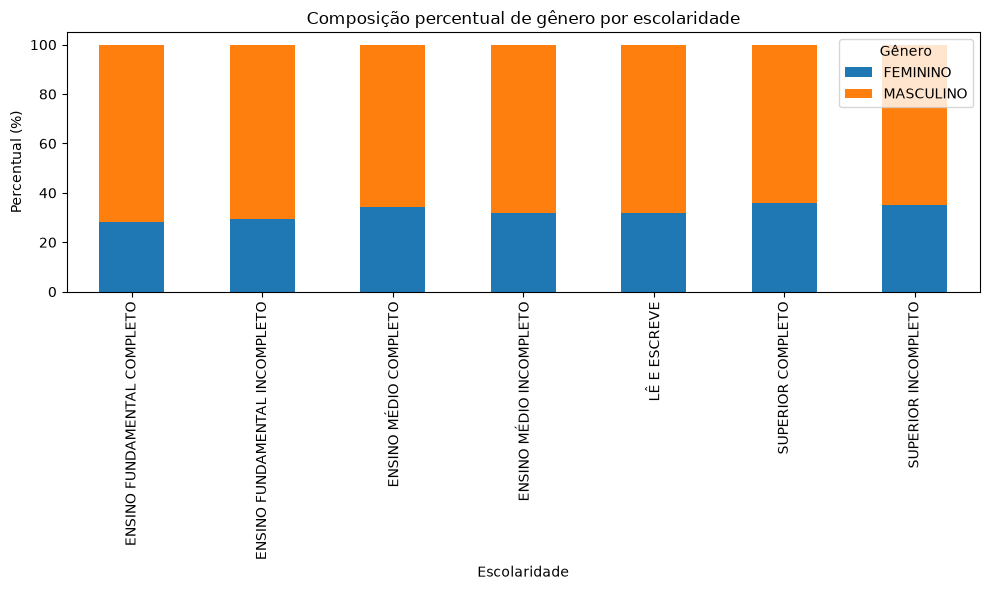

In [41]:
# Composição percentual de gênero por escolaridade

tabela_genero_escolaridade_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10, 6)
)

plt.title("Composição percentual de gênero por escolaridade")
plt.xlabel("Escolaridade")
plt.ylabel("Percentual (%)")
plt.legend(title="Gênero")

plt.tight_layout()
plt.show()

In [42]:
# Qui-quadrado: gênero × escolaridade

qui2_escolaridade, p_valor_escolaridade, graus_liberdade_escolaridade, frequencias_esperadas_escolaridade = stats.chi2_contingency(
    tabela_genero_escolaridade
)

print(f"Qui-quadrado: {qui2_escolaridade:.4f}")
print(f"p-valor: {p_valor_escolaridade:.6f}")
print(f"Graus de liberdade: {graus_liberdade_escolaridade}")

Qui-quadrado: 26.2478
p-valor: 0.000200
Graus de liberdade: 6


In [43]:
# Tabela de frequências esperadas

tabela_esperada_escolaridade = pd.DataFrame(
    frequencias_esperadas_escolaridade,
    index=tabela_genero_escolaridade.index,
    columns=tabela_genero_escolaridade.columns
)

tabela_esperada_escolaridade

genero,FEMININO,MASCULINO
escolaridade,,
ENSINO FUNDAMENTAL COMPLETO,186.995994,349.004006
ENSINO FUNDAMENTAL INCOMPLETO,214.556971,400.443029
ENSINO MÉDIO COMPLETO,1551.438782,2895.561218
ENSINO MÉDIO INCOMPLETO,251.886395,470.113605
LÊ E ESCREVE,26.165484,48.834516
SUPERIOR COMPLETO,4233.924231,7902.075769
SUPERIOR INCOMPLETO,764.032141,1425.967859


In [44]:
# Resíduos padronizados: gênero × escolaridade

residuos_padronizados_escolaridade = (
    tabela_genero_escolaridade - tabela_esperada_escolaridade
) / np.sqrt(tabela_esperada_escolaridade)

residuos_padronizados_escolaridade

genero,FEMININO,MASCULINO
escolaridade,,
ENSINO FUNDAMENTAL COMPLETO,-2.632316,1.926810
ENSINO FUNDAMENTAL INCOMPLETO,-2.222658,1.626948
ENSINO MÉDIO COMPLETO,-0.645846,0.472748
ENSINO MÉDIO INCOMPLETO,-1.316016,0.963301
LÊ E ESCREVE,-0.423341,0.309879
SUPERIOR COMPLETO,1.676319,-1.227037
SUPERIOR INCOMPLETO,0.288261,-0.211002


In [ ]:
## Insight 5: participação feminina varia conforme a escolaridade

A composição de gênero das candidaturas apresenta diferenças entre os níveis de escolaridade. Embora as candidaturas masculinas sejam predominantes em todas as categorias, observa-se uma tendência de maior participação feminina entre candidaturas com níveis mais elevados de escolaridade.

A menor proporção de candidaturas femininas foi observada entre candidatos com ensino fundamental completo, com 28,17%, seguida pelo ensino fundamental incompleto, com 29,59%. Em contraste, as maiores proporções foram observadas entre candidatos com ensino superior completo, com 35,79%, e ensino superior incompleto, com 35,25%.

O teste do qui-quadrado indicou associação estatisticamente significativa entre gênero e escolaridade (χ² = 26,2478; p < 0,001). Entretanto, o V de Cramér foi de 0,0356, indicando uma associação de baixa magnitude.

A análise dos resíduos padronizados mostrou que as principais diferenças estão concentradas nos níveis de ensino fundamental. Entre as candidaturas com ensino fundamental completo, houve menos mulheres do que o esperado, com resíduo padronizado de -2,63. No ensino fundamental incompleto, também foi observada uma quantidade de mulheres inferior à esperada, com resíduo de -2,22.

Assim, os resultados indicam que a composição de gênero apresenta diferenças segundo a escolaridade, com maior participação feminina entre candidaturas com ensino superior. Entretanto, a baixa magnitude do V de Cramér indica que a escolaridade possui associação relativamente pequena com a composição de gênero das candidaturas.

In [45]:
# Idade média por gênero e cargo

idade_genero_cargo = (
    df.groupby(["cargo", "genero"])["idade"]
    .mean()
    .unstack()
    .round(2)
)

idade_genero_cargo

genero,FEMININO,MASCULINO
cargo,,
1º SUPLENTE,52.83,53.68
2º SUPLENTE,50.51,55.00
DEPUTADO DISTRITAL,47.95,48.01
DEPUTADO ESTADUAL,47.74,49.82
DEPUTADO FEDERAL,47.23,49.65
GOVERNADOR,50.68,50.58
PRESIDENTE,39.00,60.82
SENADOR,53.94,55.80
VICE-GOVERNADOR,49.99,51.81


In [46]:
# Diferença de idade média entre candidaturas masculinas e femininas

diferenca_idade_genero_cargo = (
    idade_genero_cargo["MASCULINO"] -
    idade_genero_cargo["FEMININO"]
).sort_values(ascending=False)

diferenca_idade_genero_cargo.round(2)

cargo
PRESIDENTE            21.82
VICE-PRESIDENTE        5.32
2º SUPLENTE            4.49
DEPUTADO FEDERAL       2.42
DEPUTADO ESTADUAL      2.08
SENADOR                1.86
VICE-GOVERNADOR        1.82
1º SUPLENTE            0.85
DEPUTADO DISTRITAL     0.06
GOVERNADOR            -0.10
dtype: float64

In [47]:
# Quantidade de candidaturas por gênero e cargo

quantidade_genero_cargo = (
    df.groupby(["cargo", "genero"])
    .size()
    .unstack(fill_value=0)
)

quantidade_genero_cargo

genero,FEMININO,MASCULINO
cargo,,
1º SUPLENTE,98,227
2º SUPLENTE,102,226
DEPUTADO DISTRITAL,151,278
DEPUTADO ESTADUAL,3861,7330
DEPUTADO FEDERAL,2821,4886
GOVERNADOR,34,164
PRESIDENTE,2,11
SENADOR,70,246
VICE-GOVERNADOR,85,116


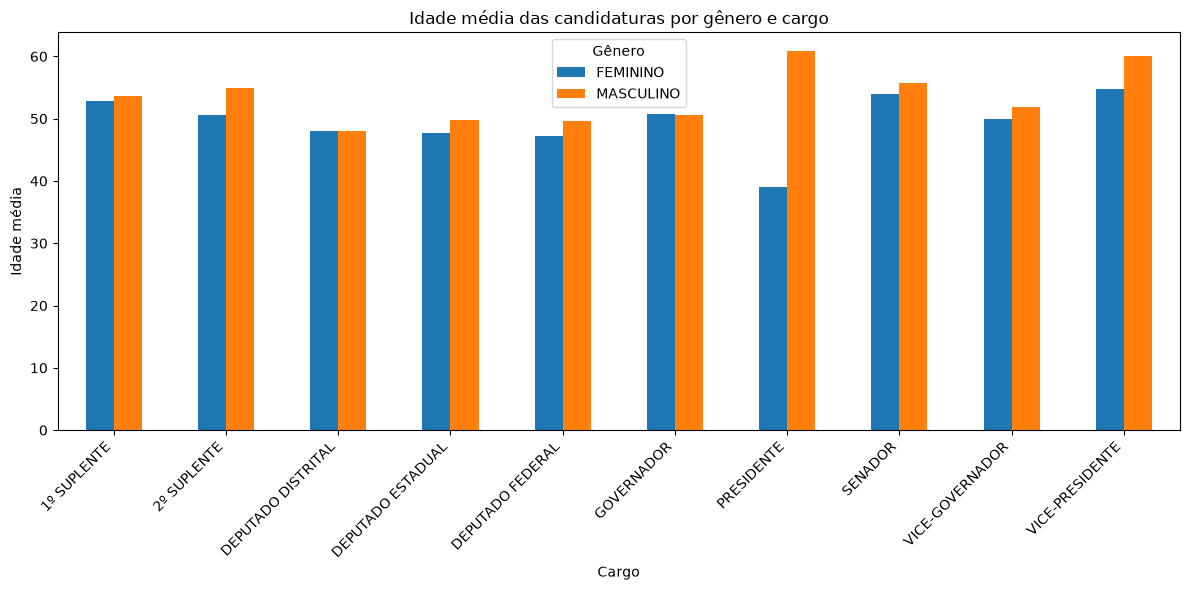

In [48]:
# Idade média por gênero e cargo

idade_genero_cargo.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Idade média das candidaturas por gênero e cargo")
plt.xlabel("Cargo")
plt.ylabel("Idade média")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Gênero")

plt.tight_layout()
plt.show()

In [49]:
idade_genero_cargo

genero,FEMININO,MASCULINO
cargo,,
1º SUPLENTE,52.83,53.68
2º SUPLENTE,50.51,55.00
DEPUTADO DISTRITAL,47.95,48.01
DEPUTADO ESTADUAL,47.74,49.82
DEPUTADO FEDERAL,47.23,49.65
GOVERNADOR,50.68,50.58
PRESIDENTE,39.00,60.82
SENADOR,53.94,55.80
VICE-GOVERNADOR,49.99,51.81


In [50]:
diferenca_idade_genero_cargo.round(2)

cargo
PRESIDENTE            21.82
VICE-PRESIDENTE        5.32
2º SUPLENTE            4.49
DEPUTADO FEDERAL       2.42
DEPUTADO ESTADUAL      2.08
SENADOR                1.86
VICE-GOVERNADOR        1.82
1º SUPLENTE            0.85
DEPUTADO DISTRITAL     0.06
GOVERNADOR            -0.10
dtype: float64

In [51]:
quantidade_genero_cargo

genero,FEMININO,MASCULINO
cargo,,
1º SUPLENTE,98,227
2º SUPLENTE,102,226
DEPUTADO DISTRITAL,151,278
DEPUTADO ESTADUAL,3861,7330
DEPUTADO FEDERAL,2821,4886
GOVERNADOR,34,164
PRESIDENTE,2,11
SENADOR,70,246
VICE-GOVERNADOR,85,116


In [ ]:
## Insight 6: diferença de idade entre gêneros varia conforme o cargo

A diferença de idade média entre candidaturas masculinas e femininas varia de acordo com o cargo disputado. Em praticamente todos os cargos, as candidaturas masculinas apresentam idade média superior à das candidaturas femininas. A exceção ocorre entre candidatos a governador, para os quais a idade média feminina foi de 50,68 anos, enquanto a masculina foi de 50,58 anos, resultando em diferença de apenas 0,10 ano.

A maior diferença foi observada entre as candidaturas à Presidência, com idade média de 39,00 anos entre as mulheres e 60,82 anos entre os homens, correspondendo a uma diferença de 21,82 anos. Entretanto, esse resultado deve ser interpretado com cautela, pois o grupo feminino possui apenas 2 candidaturas, enquanto o masculino possui 11.

Entre os demais cargos, as diferenças foram menores. As candidaturas masculinas apresentaram idade média superior em 5,32 anos para vice-presidente, 4,49 anos para 2º suplente, 2,42 anos para deputado federal, 2,08 anos para deputado estadual, 1,86 ano para senador, 1,82 ano para vice-governador e 0,85 ano para 1º suplente. Para deputado distrital, a diferença foi praticamente inexistente, com apenas 0,06 ano.

Os resultados sugerem que a diferença etária entre homens e mulheres não ocorre de maneira uniforme entre os cargos. Entretanto, as diferenças observadas em cargos com poucas candidaturas devem ser interpretadas com maior cautela, uma vez que pequenas variações individuais podem produzir diferenças consideráveis nas médias.

Assim, o cruzamento entre gênero, idade e cargo evidencia que a diferença etária entre candidaturas masculinas e femininas é particularmente elevada na disputa presidencial, enquanto nos cargos legislativos e em parte dos cargos executivos as diferenças são consideravelmente menores.

In [52]:
# Resíduos padronizados relevantes: gênero x escolaridade

residuos_relevantes_escolaridade = (
    residuos_padronizados_escolaridade
    .stack()
    .reset_index()
)

residuos_relevantes_escolaridade.columns = [
    "escolaridade",
    "genero",
    "residuo_padronizado"
]

residuos_relevantes_escolaridade = (
    residuos_relevantes_escolaridade[
        residuos_relevantes_escolaridade["residuo_padronizado"].abs() > 2
    ]
)

residuos_relevantes_escolaridade

,escolaridade,genero,residuo_padronizado
0,ENSINO FUNDAMENTAL COMPLETO,FEMININO,-2.632316
2,ENSINO FUNDAMENTAL INCOMPLETO,FEMININO,-2.222658


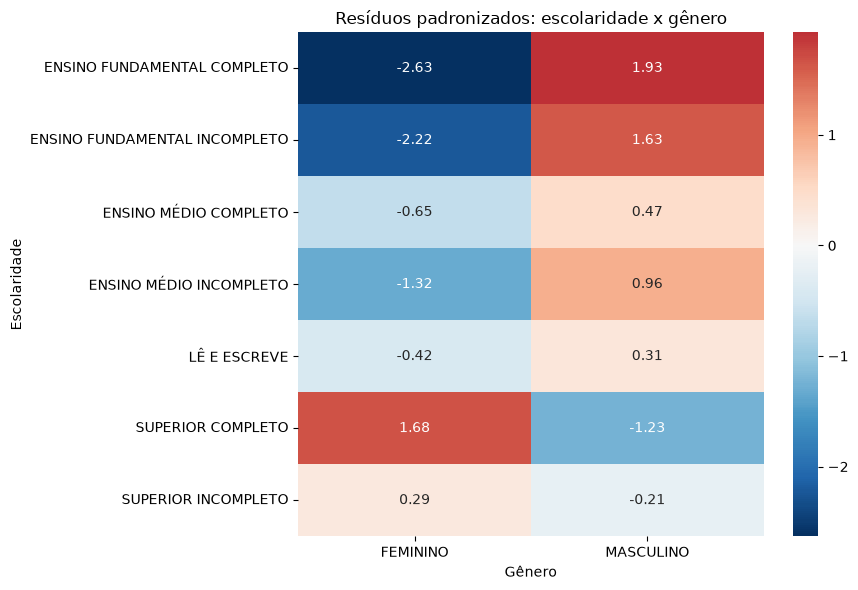

In [53]:
plt.figure(figsize=(9, 6))

sns.heatmap(
    residuos_padronizados_escolaridade,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0
)

plt.title("Resíduos padronizados: escolaridade x gênero")
plt.xlabel("Gênero")
plt.ylabel("Escolaridade")

plt.tight_layout()
plt.show()

In [ ]:
## Insight 5: composição de gênero varia conforme a escolaridade

A composição das candidaturas apresenta predominância masculina em todos os níveis de escolaridade analisados. Entretanto, a participação feminina varia entre as diferentes categorias de escolaridade, passando de 28,17% entre candidatos com ensino fundamental completo para 35,79% entre aqueles com ensino superior completo.

A maior participação feminina foi observada entre candidaturas com ensino superior completo (35,79%), seguida pelo ensino superior incompleto (35,25%) e pelo ensino médio completo (34,32%). As menores proporções femininas ocorreram entre candidatos com ensino fundamental completo (28,17%) e ensino fundamental incompleto (29,59%).

O teste do qui-quadrado indicou associação estatisticamente significativa entre gênero e escolaridade (χ² = 26,2478; p < 0,001). Entretanto, o V de Cramér foi de 0,0356, indicando que a magnitude dessa associação é baixa.

A análise dos resíduos padronizados mostrou que as principais diferenças em relação ao esperado pelo modelo de independência estão concentradas entre as candidaturas femininas com ensino fundamental completo (resíduo = -2,63) e ensino fundamental incompleto (resíduo = -2,22). Esses valores indicam uma quantidade de candidaturas femininas inferior à esperada nessas categorias.

Assim, os resultados indicam que a composição de gênero apresenta diferenças segundo a escolaridade, especialmente nos níveis mais baixos de escolaridade. Contudo, a baixa magnitude do V de Cramér indica que a escolaridade explica apenas uma pequena parcela da associação observada entre as variáveis.

In [54]:
# Concentração das candidaturas por cargo

total_legislativo = (
    df["cargo"]
    .isin(["DEPUTADO ESTADUAL", "DEPUTADO FEDERAL"])
    .sum()
)

percentual_legislativo = (
    total_legislativo / len(df) * 100
)

print(f"Candidaturas para deputado estadual e federal: {total_legislativo:,}")
print(f"Percentual do total: {percentual_legislativo:.2f}%")

Candidaturas para deputado estadual e federal: 18,898
Percentual do total: 91.20%


In [55]:
# Participação dos cargos no total de candidaturas

cargo_percentual_ordenado = (
    df["cargo"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .sort_values(ascending=False)
)

cargo_percentual_ordenado

cargo
DEPUTADO ESTADUAL     54.01
DEPUTADO FEDERAL      37.19
DEPUTADO DISTRITAL     2.07
2º SUPLENTE            1.58
1º SUPLENTE            1.57
SENADOR                1.53
VICE-GOVERNADOR        0.97
GOVERNADOR             0.96
PRESIDENTE             0.06
VICE-PRESIDENTE        0.06
Name: proportion, dtype: float64

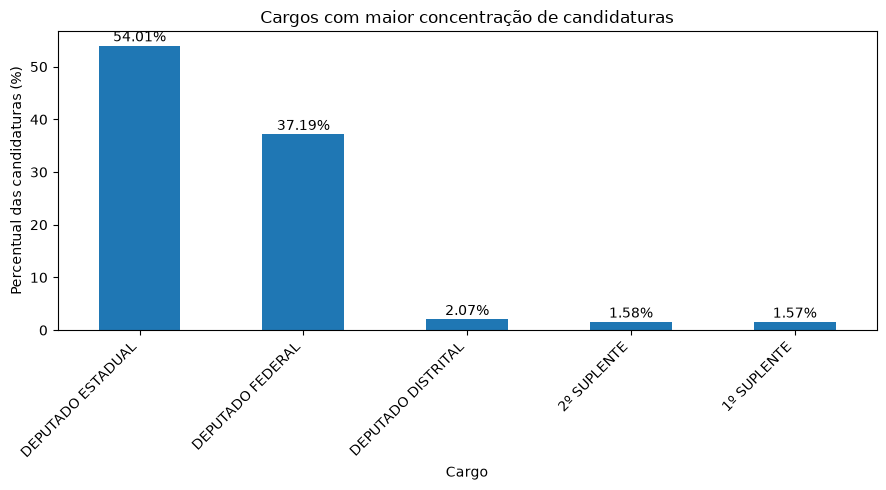

In [56]:
plt.figure(figsize=(9, 5))

cargos_principais = cargo_percentual_ordenado.head(5)

ax = cargos_principais.plot(
    kind="bar"
)

plt.title("Cargos com maior concentração de candidaturas")
plt.xlabel("Cargo")
plt.ylabel("Percentual das candidaturas (%)")

plt.xticks(rotation=45, ha="right")

for i, valor in enumerate(cargos_principais):
    ax.text(
        i,
        valor + 0.8,
        f"{valor:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

In [ ]:
## Insight 6: candidaturas estão fortemente concentradas nos cargos legislativos

A distribuição das candidaturas revela uma forte concentração nos cargos de deputado estadual e deputado federal. Do total de 20.721 candidaturas analisadas, 11.191 correspondem ao cargo de deputado estadual (54,01%) e 7.707 ao cargo de deputado federal (37,19%).

Somadas, as candidaturas aos dois cargos representam 18.898 registros, correspondendo a 91,20% de todas as candidaturas analisadas. Os demais cargos apresentam participação individual consideravelmente menor, com deputado distrital representando 2,07%, seguido pelos cargos de segundo suplente (1,58%), primeiro suplente (1,57%) e senador (1,53%).

Essa distribuição demonstra que o conjunto de dados é predominantemente composto por candidaturas destinadas ao Poder Legislativo, enquanto os cargos majoritários apresentam participação proporcionalmente menor.

Assim, análises agregadas sobre o perfil das candidaturas devem considerar essa concentração, uma vez que os resultados gerais são fortemente influenciados pela composição dos cargos legislativos, especialmente deputado estadual e deputado federal.

In [57]:
# Perfil de idade e gênero por cargo

perfil_genero_cargo = pd.DataFrame({
    "idade_feminina": idade_genero_cargo["FEMININO"],
    "idade_masculina": idade_genero_cargo["MASCULINO"],
    "diferenca_idade": diferenca_idade_genero_cargo,
    "candidaturas_femininas": quantidade_genero_cargo["FEMININO"],
    "candidaturas_masculinas": quantidade_genero_cargo["MASCULINO"]
})

perfil_genero_cargo["total_candidaturas"] = (
    perfil_genero_cargo["candidaturas_femininas"]
    + perfil_genero_cargo["candidaturas_masculinas"]
)

perfil_genero_cargo["participacao_feminina"] = (
    perfil_genero_cargo["candidaturas_femininas"]
    / perfil_genero_cargo["total_candidaturas"]
    * 100
).round(2)

perfil_genero_cargo = perfil_genero_cargo.sort_values(
    "diferenca_idade",
    ascending=False
)

perfil_genero_cargo.round(2)

,idade_feminina,idade_masculina,diferenca_idade,candidaturas_femininas,candidaturas_masculinas,total_candidaturas,participacao_feminina
cargo,,,,,,,
PRESIDENTE,39.00,60.82,21.82,2,11,13,15.38
VICE-PRESIDENTE,54.80,60.12,5.32,5,8,13,38.46
2º SUPLENTE,50.51,55.00,4.49,102,226,328,31.10
DEPUTADO FEDERAL,47.23,49.65,2.42,2821,4886,7707,36.60
DEPUTADO ESTADUAL,47.74,49.82,2.08,3861,7330,11191,34.50
SENADOR,53.94,55.80,1.86,70,246,316,22.15
VICE-GOVERNADOR,49.99,51.81,1.82,85,116,201,42.29
1º SUPLENTE,52.83,53.68,0.85,98,227,325,30.15
DEPUTADO DISTRITAL,47.95,48.01,0.06,151,278,429,35.20


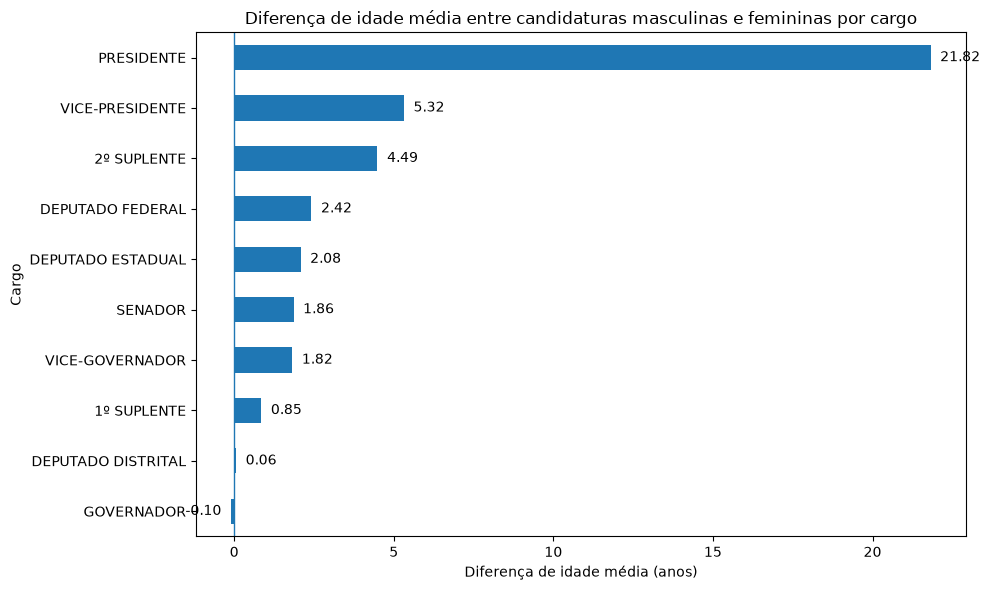

In [58]:
plt.figure(figsize=(10, 6))

perfil_grafico = perfil_genero_cargo.sort_values(
    "diferenca_idade",
    ascending=True
)

ax = perfil_grafico["diferenca_idade"].plot(
    kind="barh"
)

plt.axvline(0, linewidth=1)

plt.title("Diferença de idade média entre candidaturas masculinas e femininas por cargo")
plt.xlabel("Diferença de idade média (anos)")
plt.ylabel("Cargo")

for i, valor in enumerate(perfil_grafico["diferenca_idade"]):
    ax.text(
        valor + (0.3 if valor >= 0 else -0.3),
        i,
        f"{valor:.2f}",
        va="center",
        ha="left" if valor >= 0 else "right"
    )

plt.tight_layout()
plt.show()

In [ ]:
## Insight 7: diferenças de idade entre homens e mulheres variam conforme o cargo

A idade média das candidaturas masculinas é superior à das candidaturas femininas na maioria dos cargos analisados. As maiores diferenças foram observadas entre candidatos à Presidência, com diferença de 21,82 anos, à Vice-Presidência, com 5,32 anos, e ao cargo de 2º suplente, com 4,49 anos.

Entretanto, as diferenças observadas nos cargos majoritários devem ser interpretadas com cautela devido ao reduzido número de candidaturas femininas. Para a Presidência, por exemplo, foram identificadas apenas 2 candidaturas femininas, em comparação a 11 masculinas. Na Vice-Presidência, foram 5 candidaturas femininas e 8 masculinas.

Nos cargos com maior número de candidaturas, as diferenças são mais moderadas. Entre deputados federais, a idade média foi de 47,23 anos para mulheres e 49,65 anos para homens, uma diferença de 2,42 anos. Entre deputados estaduais, as médias foram de 47,74 e 49,82 anos, respectivamente, correspondendo a uma diferença de 2,08 anos.

Em alguns cargos, as idades médias são praticamente equivalentes. Entre candidatos a deputado distrital, a diferença foi de apenas 0,06 ano, enquanto entre candidatos a governador as mulheres apresentaram idade média 0,10 ano superior à dos homens.

Os resultados indicam, portanto, que a diferença de idade entre candidaturas masculinas e femininas não apresenta um padrão uniforme entre os cargos. Embora as candidaturas masculinas sejam, em geral, mais velhas, as diferenças mais expressivas estão concentradas em cargos com poucos registros, enquanto nos cargos legislativos com maior número de candidaturas as diferenças são relativamente pequenas.

In [ ]:
# Síntese dos principais insights eleitorais

A análise das 20.721 candidaturas permitiu identificar diferentes padrões relacionados ao perfil demográfico e político dos candidatos nas Eleições Gerais de 2026. Os resultados evidenciam predominância masculina, forte concentração das candidaturas em cargos legislativos e diferenças na composição das candidaturas segundo gênero, cor/raça e escolaridade.

### Predominância masculina

As candidaturas masculinas representam 65,11% do conjunto analisado, enquanto as candidaturas femininas correspondem a 34,89%. A predominância masculina é observada em todos os cargos analisados, embora sua intensidade varie entre as posições eleitorais.

A maior participação feminina ocorre entre candidaturas a vice-governador, com 42,29%, seguida por vice-presidente, com 38,46%, e deputado federal, com 36,60%. As menores proporções femininas são observadas entre candidatos à Presidência, com 15,38%, ao Governo estadual, com 17,17%, e ao Senado, com 22,15%.

O teste do qui-quadrado identificou associação estatisticamente significativa entre gênero e cargo (χ² = 73,0353; p < 0,001). Entretanto, o V de Cramér foi de 0,0594, indicando baixa magnitude da associação.

### Concentração das candidaturas nos cargos legislativos

A distribuição das candidaturas é fortemente concentrada nos cargos de deputado estadual e deputado federal. Juntos, esses dois cargos correspondem a 18.898 candidaturas, ou 91,20% do total analisado.

Essa concentração é importante para a interpretação dos resultados gerais, pois o perfil agregado das candidaturas é fortemente influenciado pelas características desses dois cargos.

### Diferenças de idade

A idade média das candidaturas femininas foi de 47,75 anos, enquanto a das candidaturas masculinas foi de aproximadamente 50,02 anos. O teste de Welch indicou diferença estatisticamente significativa entre as médias (p < 0,001), mas o tamanho do efeito foi pequeno (Cohen's d = -0,1946).

As diferenças de idade também variam conforme o cargo. Entre os cargos com maior número de candidaturas, as diferenças entre homens e mulheres são relativamente pequenas, como 2,42 anos entre candidatos a deputado federal e 2,08 anos entre candidatos a deputado estadual.

### Cor/raça e gênero

A composição das candidaturas também apresenta diferenças segundo a cor/raça. A participação feminina é maior entre candidatos indígenas (44,84%), pretos (44,39%) e amarelos (40,74%), enquanto corresponde a 33,81% entre candidatos pardos e 32,80% entre candidatos brancos.

O teste do qui-quadrado indicou associação estatisticamente significativa entre cor/raça e gênero (χ² = 145,6734; p < 0,001). Entretanto, o V de Cramér foi de 0,0838, indicando baixa magnitude da associação.

Os resíduos padronizados mostram que as diferenças mais expressivas estão concentradas entre candidaturas brancas e pretas. Entre candidatos brancos, houve menos candidaturas femininas e mais masculinas do que o esperado pelo modelo de independência. Entre candidatos pretos, ocorreu o padrão inverso, com maior presença feminina do que a esperada.

### Escolaridade e gênero

A participação feminina varia entre os níveis de escolaridade, embora as candidaturas masculinas permaneçam predominantes em todas as categorias.

A maior participação feminina ocorre entre candidatos com ensino superior completo, com 35,79%, seguida pelo ensino superior incompleto, com 35,25%. A menor participação feminina é observada entre candidatos com ensino fundamental completo, com 28,17%.

O teste do qui-quadrado indicou associação estatisticamente significativa entre gênero e escolaridade (χ² = 26,2478; p < 0,001), mas o V de Cramér foi de 0,0356, indicando baixa magnitude da associação. Os principais desvios em relação ao esperado foram observados entre as candidaturas femininas com ensino fundamental completo e ensino fundamental incompleto.

### Cargos e diferenças etárias entre os gêneros

A comparação das idades médias segundo gênero e cargo mostrou que as candidaturas masculinas apresentam idade média superior à feminina na maioria dos cargos.

As maiores diferenças foram observadas na Presidência, com 21,82 anos, e na Vice-Presidência, com 5,32 anos. Entretanto, esses resultados devem ser interpretados com cautela devido ao pequeno número de candidaturas nesses cargos. Na Presidência, foram identificadas apenas 2 candidaturas femininas e 11 masculinas.

Nos cargos legislativos, que concentram a maior parte das observações, as diferenças são consideravelmente menores. Entre deputados federais, a diferença foi de 2,42 anos, enquanto entre deputados estaduais foi de 2,08 anos.

### Síntese geral

De forma geral, os resultados mostram que o perfil das candidaturas apresenta diferenças estatisticamente significativas segundo gênero, cargo, cor/raça e escolaridade. Contudo, os valores dos tamanhos de efeito indicam que essas associações possuem baixa magnitude.

Assim, a significância estatística observada deve ser interpretada conjuntamente com a magnitude dos efeitos e com a distribuição das observações entre as categorias. Em particular, diferenças observadas em cargos com poucos candidatos devem ser analisadas com maior cautela do que padrões identificados nos cargos com grande número de candidaturas.